# Walmart M5 Dynamic Pricing

## Business Objective

Notebook 05 accepted the development demand-forecasting model and documented its remaining limitations.

This notebook adds the **dynamic-pricing layer**.

The goal is to answer:

> Given a current price and a baseline demand forecast, what price would maximize expected revenue while staying within reasonable pricing constraints?

This notebook deliberately separates two ideas:

1. **Demand forecasting**  
   Predict expected demand under normal/current conditions.

2. **Price-response modeling**  
   Estimate how demand may change if price changes.

A demand model by itself does **not** prove causal price elasticity. Therefore this notebook uses a transparent, scenario-based pricing framework rather than pretending the forecasting model learned true causal price response.

We will:

- load model outputs and feature data
- estimate a conservative development elasticity from historical item-level behavior
- generate candidate prices around the current price
- convert baseline demand into scenario demand
- estimate revenue under each candidate price
- enforce pricing guardrails
- recommend a price
- evaluate recommendations across a test sample
- save pricing outputs for the future API / dashboard

## 1. Import Libraries

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

## 2. Define Project Paths

Notebook 04 saved the trained forecasting pipeline and model metadata.

Notebook 05 saved evaluation outputs.

Notebook 03 saved the feature-engineered dataset used for modeling.

In [2]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
MODELING_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"
PRICING_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "pricing"

FEATURE_FILE = (
    PROCESSED_DIR
    / "features_CA_1_200_items.csv"
)

MODEL_FILE = (
    MODEL_DIR
    / "demand_forecast_model.joblib"
)

METADATA_FILE = (
    MODEL_DIR
    / "demand_forecast_model_metadata.json"
)

TEST_PREDICTIONS_FILE = (
    MODELING_OUTPUT_DIR
    / "test_predictions.csv"
)

PRICING_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PRICING_RECOMMENDATIONS_FILE = (
    PRICING_OUTPUT_DIR
    / "pricing_recommendations.csv"
)

## 3. Load Modeling and Pricing Inputs

In [3]:
features = pd.read_csv(
    FEATURE_FILE,
    parse_dates=["date"],
)

test_predictions = pd.read_csv(
    TEST_PREDICTIONS_FILE,
    parse_dates=["date"],
)

forecast_pipeline = joblib.load(
    MODEL_FILE
)

with open(
    METADATA_FILE,
    "r",
    encoding="utf-8",
) as file:
    metadata = json.load(file)

print("Feature data:", features.shape)
print("Test predictions:", test_predictions.shape)
print("Forecast model:", metadata["selected_model"])

Feature data: (382600, 47)
Test predictions: (5600, 7)
Forecast model: poisson_hist_gradient_boosting


## 4. Pricing Scope and Assumptions

This notebook is a **development pricing simulation**, not a causal production pricing system.

Important assumptions:

- the Notebook 04 model provides the baseline demand forecast
- price changes affect demand through a separate elasticity assumption
- candidate prices stay within a limited range around the current price
- recommended prices cannot be negative
- products without a valid current price are excluded
- profitability is not optimized yet because product-level cost data is not available

Therefore the optimization target is **expected revenue**, not profit.

Revenue:

`price × expected demand`

## 5. Historical Price-Response Exploration

Notebook 02 showed that aggregate price and demand had a positive raw correlation, which was **not causal**.

For pricing, we instead look within each item and study how weekly demand changes when the item's price changes.

Even this remains observational data, so the resulting elasticity is treated as a development assumption rather than a causal estimate.

In [4]:
pricing_history = features[
    [
        "date",
        "item_id",
        "store_id",
        "units_sold",
        "sell_price",
    ]
].copy()

pricing_history = pricing_history.loc[
    pricing_history["sell_price"].notna()
    & (pricing_history["sell_price"] > 0)
].copy()

pricing_history["week_start"] = (
    pricing_history["date"]
    - pd.to_timedelta(
        pricing_history["date"].dt.dayofweek,
        unit="D",
    )
)

weekly_item = (
    pricing_history
    .groupby(
        [
            "item_id",
            "store_id",
            "week_start",
        ],
        as_index=False,
    )
    .agg(
        weekly_units=("units_sold", "sum"),
        weekly_price=("sell_price", "mean"),
    )
)

weekly_item.head()

,item_id,store_id,week_start,weekly_units,weekly_price
0,FOODS_1_001,CA_1,2011-02-21,4,2.0
1,FOODS_1_001,CA_1,2011-02-28,16,2.0
2,FOODS_1_001,CA_1,2011-03-07,12,2.0
3,FOODS_1_001,CA_1,2011-03-14,3,2.0
4,FOODS_1_001,CA_1,2011-03-21,8,2.0


## 6. Estimate Development Price Elasticity

For each item-store series, compare percentage price change with percentage demand change between consecutive weeks.

Elasticity approximation:

`% change in demand / % change in price`

We keep only observations where price actually changed.

Extreme elasticity values are clipped because observational retail data can contain promotions, availability changes, seasonality, and noise.

In [5]:
weekly_item = weekly_item.sort_values(
    [
        "item_id",
        "store_id",
        "week_start",
    ]
).copy()

weekly_item["previous_price"] = (
    weekly_item
    .groupby(
        [
            "item_id",
            "store_id",
        ]
    )["weekly_price"]
    .shift(1)
)

weekly_item["previous_units"] = (
    weekly_item
    .groupby(
        [
            "item_id",
            "store_id",
        ]
    )["weekly_units"]
    .shift(1)
)

weekly_item["price_change_pct"] = (
    weekly_item["weekly_price"]
    / weekly_item["previous_price"]
    - 1
)

weekly_item["demand_change_pct"] = (
    weekly_item["weekly_units"]
    / weekly_item["previous_units"].replace(0, np.nan)
    - 1
)

elasticity_observations = weekly_item.loc[
    weekly_item["price_change_pct"].abs() >= 0.01
].copy()

elasticity_observations["elasticity"] = (
    elasticity_observations["demand_change_pct"]
    / elasticity_observations["price_change_pct"]
)

elasticity_observations = elasticity_observations.loc[
    elasticity_observations["elasticity"]
    .replace([np.inf, -np.inf], np.nan)
    .notna()
].copy()

elasticity_observations["elasticity"] = (
    elasticity_observations["elasticity"]
    .clip(-5, 2)
)

elasticity_observations[
    "elasticity"
].describe()

count    563.000000
mean      -1.336846
std        3.227878
min       -5.000000
25%       -5.000000
50%        0.000000
75%        2.000000
max        2.000000
Name: elasticity, dtype: float64

## 7. Build Item-Level Elasticity Assumptions

Economic demand elasticity is usually negative: higher price tends to reduce demand.

Because the observed estimates are noisy, we use:

- the item's median historical elasticity when enough observations exist
- otherwise a conservative fallback elasticity

We constrain the usable development elasticity to:

`-3.0 to -0.2`

This avoids implausibly extreme pricing responses.

In [6]:
MIN_ELASTICITY_OBSERVATIONS = 3
FALLBACK_ELASTICITY = -1.0

item_elasticity = (
    elasticity_observations
    .groupby(
        [
            "item_id",
            "store_id",
        ],
        as_index=False,
    )
    .agg(
        estimated_elasticity=("elasticity", "median"),
        elasticity_observations=("elasticity", "count"),
    )
)

item_elasticity["usable_elasticity"] = np.where(
    (
        item_elasticity["elasticity_observations"]
        >= MIN_ELASTICITY_OBSERVATIONS
    )
    & (
        item_elasticity["estimated_elasticity"]
        < 0
    ),
    item_elasticity["estimated_elasticity"],
    FALLBACK_ELASTICITY,
)

item_elasticity["usable_elasticity"] = (
    item_elasticity["usable_elasticity"]
    .clip(-3.0, -0.2)
)

item_elasticity.head()

,item_id,store_id,estimated_elasticity,elasticity_observations,usable_elasticity
0,FOODS_1_001,CA_1,-1.500000,2,-1.0
1,FOODS_1_002,CA_1,-1.500000,4,-1.5
2,FOODS_1_003,CA_1,-1.500000,2,-1.0
3,FOODS_1_004,CA_1,-4.522727,6,-3.0
4,FOODS_1_006,CA_1,-4.016402,4,-3.0


## 8. Create Pricing Evaluation Base

Join the final test predictions to current price information.

Each row now has:

- actual demand
- baseline predicted demand
- current price
- price elasticity assumption

In [7]:
pricing_base = test_predictions.merge(
    features[
        [
            "date",
            "item_id",
            "store_id",
            "sell_price",
            "price_available",
        ]
    ],
    on=[
        "date",
        "item_id",
        "store_id",
    ],
    how="left",
    validate="one_to_one",
)

pricing_base = pricing_base.merge(
    item_elasticity[
        [
            "item_id",
            "store_id",
            "usable_elasticity",
            "elasticity_observations",
        ]
    ],
    on=[
        "item_id",
        "store_id",
    ],
    how="left",
    validate="many_to_one",
)

pricing_base["usable_elasticity"] = (
    pricing_base["usable_elasticity"]
    .fillna(FALLBACK_ELASTICITY)
)

pricing_base["elasticity_observations"] = (
    pricing_base["elasticity_observations"]
    .fillna(0)
)

pricing_base = pricing_base.loc[
    pricing_base["sell_price"].notna()
    & (pricing_base["sell_price"] > 0)
].copy()

print(
    "Pricing-eligible rows:",
    f"{len(pricing_base):,}",
)

pricing_base.head()

Pricing-eligible rows: 5,600


,date,item_id,store_id,units_sold,prediction,residual,absolute_error,sell_price,price_available,usable_elasticity,elasticity_observations
0,2016-04-25,FOODS_1_001,CA_1,2,0.811261,1.188739,1.188739,2.24,1,-1.0,2.0
1,2016-04-25,FOODS_1_002,CA_1,0,0.450272,-0.450272,0.450272,9.48,1,-1.5,4.0
2,2016-04-25,FOODS_1_003,CA_1,3,0.702118,2.297882,2.297882,3.23,1,-1.0,2.0
3,2016-04-25,FOODS_1_004,CA_1,0,0.056105,-0.056105,0.056105,1.96,1,-3.0,6.0
4,2016-04-25,FOODS_1_005,CA_1,1,1.291144,-0.291144,0.291144,3.54,1,-1.0,0.0


## 9. Define Candidate Price Guardrails

To avoid unrealistic recommendations, candidate prices are limited to:

- maximum **10% decrease**
- maximum **10% increase**
- 2.5% steps

These constraints can later become configurable business rules in the API.

In [8]:
PRICE_CHANGE_OPTIONS = np.array([
    -0.10,
    -0.075,
    -0.05,
    -0.025,
    0.00,
    0.025,
    0.05,
    0.075,
    0.10,
])

PRICE_FLOOR = 0.01

## 10. Price-Response Function

A constant-elasticity demand curve is used for scenario analysis:

`scenario demand = baseline demand × (new price / current price) ^ elasticity`

Example:

- elasticity = `-1`
- price increases by 10%
- expected demand decreases by roughly 9%

This is transparent and easy to replace later with a stronger causal price-response model.

In [9]:
def estimate_scenario_demand(
    baseline_demand,
    current_price,
    candidate_price,
    elasticity,
):
    if (
        baseline_demand < 0
        or current_price <= 0
        or candidate_price <= 0
    ):
        return np.nan

    relative_price = (
        candidate_price
        / current_price
    )

    scenario_demand = (
        baseline_demand
        * relative_price ** elasticity
    )

    return max(
        scenario_demand,
        0,
    )

## 11. Generate Candidate Prices for One Example

Inspect the pricing mechanics on one test observation before scaling the logic.

In [10]:
example_row = pricing_base.iloc[0]

example_candidates = []

for change_pct in PRICE_CHANGE_OPTIONS:

    current_price = (
        example_row["sell_price"]
    )

    candidate_price = max(
        current_price
        * (1 + change_pct),
        PRICE_FLOOR,
    )

    expected_demand = (
        estimate_scenario_demand(
            baseline_demand=example_row["prediction"],
            current_price=current_price,
            candidate_price=candidate_price,
            elasticity=example_row["usable_elasticity"],
        )
    )

    expected_revenue = (
        candidate_price
        * expected_demand
    )

    example_candidates.append({
        "price_change_pct": change_pct,
        "candidate_price": candidate_price,
        "expected_demand": expected_demand,
        "expected_revenue": expected_revenue,
    })

example_candidates_df = pd.DataFrame(
    example_candidates
)

example_candidates_df

,price_change_pct,candidate_price,expected_demand,expected_revenue
0,-0.100,2.016,0.901401,1.817224
1,-0.075,2.072,0.877039,1.817224
2,-0.050,2.128,0.853959,1.817224
3,-0.025,2.184,0.832062,1.817224
4,0.000,2.240,0.811261,1.817224
5,0.025,2.296,0.791474,1.817224
6,0.050,2.352,0.772629,1.817224
7,0.075,2.408,0.754661,1.817224
8,0.100,2.464,0.737510,1.817224


## 12. Visualize the Example Price-Revenue Curve

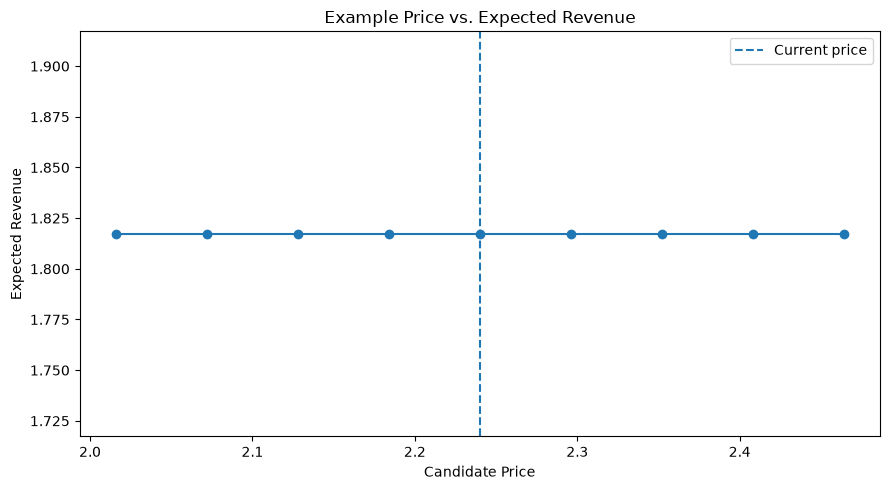

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    example_candidates_df[
        "candidate_price"
    ],
    example_candidates_df[
        "expected_revenue"
    ],
    marker="o",
)

ax.axvline(
    example_row["sell_price"],
    linestyle="--",
    label="Current price",
)

ax.set_title(
    "Example Price vs. Expected Revenue"
)
ax.set_xlabel("Candidate Price")
ax.set_ylabel("Expected Revenue")
ax.legend()

plt.tight_layout()
plt.show()

## 13. Pricing Recommendation Function

For each row:

1. generate allowed candidate prices
2. estimate scenario demand
3. estimate scenario revenue
4. select the candidate with the highest expected revenue

In [12]:
def recommend_price_for_row(
    row,
):
    current_price = row["sell_price"]
    baseline_demand = row["prediction"]
    elasticity = row["usable_elasticity"]

    scenarios = []

    for change_pct in PRICE_CHANGE_OPTIONS:

        candidate_price = max(
            current_price
            * (1 + change_pct),
            PRICE_FLOOR,
        )

        expected_demand = (
            estimate_scenario_demand(
                baseline_demand=baseline_demand,
                current_price=current_price,
                candidate_price=candidate_price,
                elasticity=elasticity,
            )
        )

        expected_revenue = (
            candidate_price
            * expected_demand
        )

        scenarios.append({
            "recommended_price": candidate_price,
            "recommended_change_pct": change_pct,
            "expected_demand": expected_demand,
            "expected_revenue": expected_revenue,
        })

    scenario_df = pd.DataFrame(
        scenarios
    )

    best = scenario_df.loc[
        scenario_df[
            "expected_revenue"
        ].idxmax()
    ]

    return best

## 14. Generate Pricing Recommendations

Apply the pricing function to all pricing-eligible test rows.

In [13]:
recommendations = (
    pricing_base
    .apply(
        recommend_price_for_row,
        axis=1,
    )
)

pricing_results = pd.concat(
    [
        pricing_base.reset_index(
            drop=True
        ),
        recommendations.reset_index(
            drop=True
        ),
    ],
    axis=1,
)

pricing_results[
    [
        "date",
        "item_id",
        "sell_price",
        "prediction",
        "usable_elasticity",
        "recommended_price",
        "recommended_change_pct",
        "expected_demand",
        "expected_revenue",
    ]
].head()

,date,item_id,sell_price,prediction,usable_elasticity,recommended_price,recommended_change_pct,expected_demand,expected_revenue
0,2016-04-25,FOODS_1_001,2.24,0.811261,-1.0,2.184,-0.025,0.832062,1.817224
1,2016-04-25,FOODS_1_002,9.48,0.450272,-1.5,8.532,-0.100,0.527364,4.499474
2,2016-04-25,FOODS_1_003,3.23,0.702118,-1.0,2.907,-0.100,0.780132,2.267842
3,2016-04-25,FOODS_1_004,1.96,0.056105,-3.0,1.764,-0.100,0.076962,0.135761
4,2016-04-25,FOODS_1_005,3.54,1.291144,-1.0,3.186,-0.100,1.434605,4.570650


## 15. Compare Current vs. Recommended Expected Revenue

Current expected revenue uses:

`current price × baseline predicted demand`

Recommended expected revenue uses:

`recommended price × scenario demand`

In [14]:
pricing_results["current_expected_revenue"] = (
    pricing_results["sell_price"]
    * pricing_results["prediction"]
)

pricing_results["expected_revenue_lift"] = (
    pricing_results["expected_revenue"]
    - pricing_results["current_expected_revenue"]
)

pricing_results["expected_revenue_lift_pct"] = (
    pricing_results["expected_revenue_lift"]
    / pricing_results[
        "current_expected_revenue"
    ].replace(0, np.nan)
)

pricing_results[
    [
        "current_expected_revenue",
        "expected_revenue",
        "expected_revenue_lift",
        "expected_revenue_lift_pct",
    ]
].describe()

,current_expected_revenue,expected_revenue,expected_revenue_lift,expected_revenue_lift_pct
count,5600.000000,5600.000000,5.600000e+03,5.600000e+03
mean,3.943169,4.142936,1.997666e-01,4.508051e-02
std,3.232210,3.489915,5.191005e-01,8.456439e-02
min,0.036344,0.036344,0.000000e+00,0.000000e+00
25%,1.925605,1.971688,2.220446e-16,1.221846e-16
50%,2.998276,3.152739,4.440892e-16,1.709073e-16
75%,4.948207,5.188286,1.441976e-01,5.409255e-02
max,28.100908,30.256989,5.748828e+00,2.345679e-01


## 16. Pricing Recommendation Distribution

Inspect how often the engine recommends:

- lowering price
- keeping price unchanged
- raising price

In [15]:
pricing_results["pricing_action"] = np.select(
    [
        pricing_results[
            "recommended_change_pct"
        ] < 0,
        pricing_results[
            "recommended_change_pct"
        ] > 0,
    ],
    [
        "Decrease",
        "Increase",
    ],
    default="Keep",
)

pricing_action_summary = (
    pricing_results[
        "pricing_action"
    ]
    .value_counts()
    .rename_axis(
        "pricing_action"
    )
    .reset_index(
        name="rows"
    )
)

pricing_action_summary["share"] = (
    pricing_action_summary["rows"]
    / pricing_action_summary["rows"].sum()
)

pricing_action_summary

,pricing_action,rows,share
0,Decrease,4880,0.871429
1,Increase,705,0.125893
2,Keep,15,0.002679


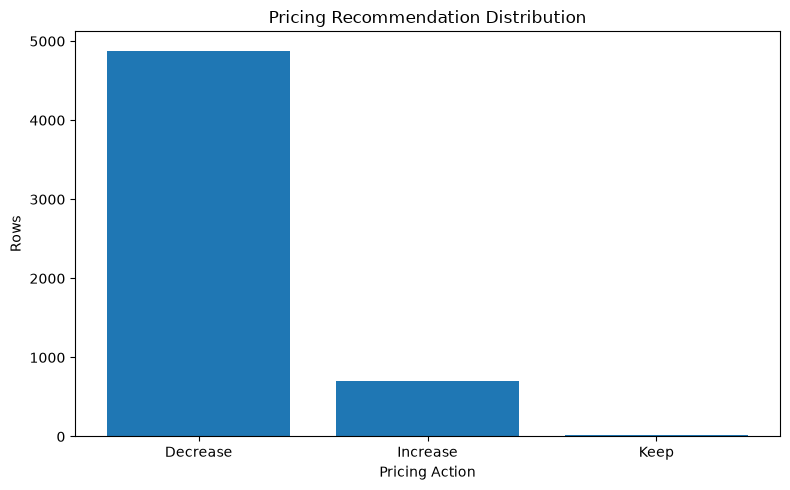

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    pricing_action_summary[
        "pricing_action"
    ],
    pricing_action_summary[
        "rows"
    ],
)

ax.set_title(
    "Pricing Recommendation Distribution"
)
ax.set_xlabel("Pricing Action")
ax.set_ylabel("Rows")

plt.tight_layout()
plt.show()

## 17. Aggregate Expected Revenue Impact

Sum current and recommended expected revenue across all pricing-eligible test observations.

In [17]:
aggregate_current_revenue = (
    pricing_results[
        "current_expected_revenue"
    ].sum()
)

aggregate_recommended_revenue = (
    pricing_results[
        "expected_revenue"
    ].sum()
)

aggregate_revenue_lift = (
    aggregate_recommended_revenue
    - aggregate_current_revenue
)

aggregate_revenue_lift_pct = (
    aggregate_revenue_lift
    / aggregate_current_revenue
)

print(
    "Current expected revenue:",
    f"${aggregate_current_revenue:,.2f}",
)

print(
    "Recommended expected revenue:",
    f"${aggregate_recommended_revenue:,.2f}",
)

print(
    "Expected revenue lift:",
    f"${aggregate_revenue_lift:,.2f}",
)

print(
    "Expected revenue lift percent:",
    f"{aggregate_revenue_lift_pct:.2%}",
)

Current expected revenue: $22,081.75
Recommended expected revenue: $23,200.44
Expected revenue lift: $1,118.69
Expected revenue lift percent: 5.07%


## 18. Revenue Lift by Product

Identify products with the largest projected revenue opportunities.

In [18]:
product_pricing_summary = (
    pricing_results
    .groupby(
        "item_id",
        as_index=False,
    )
    .agg(
        current_expected_revenue=(
            "current_expected_revenue",
            "sum",
        ),
        recommended_expected_revenue=(
            "expected_revenue",
            "sum",
        ),
        average_current_price=(
            "sell_price",
            "mean",
        ),
        average_recommended_price=(
            "recommended_price",
            "mean",
        ),
        average_elasticity=(
            "usable_elasticity",
            "mean",
        ),
    )
)

product_pricing_summary[
    "expected_revenue_lift"
] = (
    product_pricing_summary[
        "recommended_expected_revenue"
    ]
    - product_pricing_summary[
        "current_expected_revenue"
    ]
)

product_pricing_summary[
    "expected_revenue_lift_pct"
] = (
    product_pricing_summary[
        "expected_revenue_lift"
    ]
    / product_pricing_summary[
        "current_expected_revenue"
    ].replace(0, np.nan)
)

product_pricing_summary = (
    product_pricing_summary
    .sort_values(
        "expected_revenue_lift",
        ascending=False,
    )
)

product_pricing_summary.head(20)

,item_id,current_expected_revenue,recommended_expected_revenue,average_current_price,average_recommended_price,average_elasticity,expected_revenue_lift,expected_revenue_lift_pct
183,FOODS_1_187,387.348466,478.207983,9.942857,8.948571,-3.000000,90.859517,0.234568
41,FOODS_1_043,373.949367,461.665885,1.960000,1.764000,-3.000000,87.716518,0.234568
53,FOODS_1_055,309.209722,381.740397,4.380000,3.942000,-3.000000,72.530676,0.234568
107,FOODS_1_110,289.253586,357.103192,1.960000,1.764000,-3.000000,67.849607,0.234568
3,FOODS_1_004,185.626376,229.168365,1.960000,1.764000,-3.000000,43.541989,0.234568
150,FOODS_1_153,150.476236,185.773131,1.980000,1.782000,-3.000000,35.296895,0.234568
197,FOODS_1_201,149.401548,184.446356,2.240000,2.016000,-3.000000,35.044808,0.234568
34,FOODS_1_036,130.886464,161.588227,1.780000,1.602000,-3.000000,30.701763,0.234568
168,FOODS_1_172,128.408764,158.529339,1.980000,1.782000,-3.000000,30.120574,0.234568
147,FOODS_1_150,127.289765,157.147858,5.280000,4.752000,-3.000000,29.858093,0.234568


## 19. Elasticity Confidence Flag

Not every item has enough historical price changes to estimate a useful elasticity.

Create a simple confidence label:

- `Observed` — enough historical elasticity observations
- `Fallback` — uses the default elasticity

In [19]:
pricing_results[
    "elasticity_source"
] = np.where(
    pricing_results[
        "elasticity_observations"
    ] >= MIN_ELASTICITY_OBSERVATIONS,
    "Observed",
    "Fallback",
)

elasticity_source_summary = (
    pricing_results[
        "elasticity_source"
    ]
    .value_counts()
    .rename_axis(
        "elasticity_source"
    )
    .reset_index(
        name="rows"
    )
)

elasticity_source_summary

,elasticity_source,rows
0,Fallback,2912
1,Observed,2688


## 20. Conservative Recommendation Filter

A pricing engine should not blindly act on every modeled improvement.

For a more conservative business rule, flag recommendations only when:

- expected revenue lift is at least **1%**
- baseline predicted demand is positive
- current price exists

In [20]:
MIN_REVENUE_LIFT_PCT = 0.01

pricing_results[
    "recommendation_actionable"
] = (
    pricing_results[
        "expected_revenue_lift_pct"
    ]
    >= MIN_REVENUE_LIFT_PCT
) & (
    pricing_results[
        "prediction"
    ] > 0
) & (
    pricing_results[
        "sell_price"
    ] > 0
)

print(
    "Actionable recommendations:",
    f"{pricing_results['recommendation_actionable'].sum():,}",
)

print(
    "Share actionable:",
    f"{pricing_results['recommendation_actionable'].mean():.2%}",
)

Actionable recommendations: 1,624
Share actionable: 29.00%


## 21. Inspect Top Actionable Recommendations

In [21]:
top_recommendations = (
    pricing_results.loc[
        pricing_results[
            "recommendation_actionable"
        ]
    ]
    .sort_values(
        "expected_revenue_lift",
        ascending=False,
    )
    [
        [
            "date",
            "item_id",
            "store_id",
            "sell_price",
            "recommended_price",
            "recommended_change_pct",
            "prediction",
            "expected_demand",
            "usable_elasticity",
            "elasticity_source",
            "current_expected_revenue",
            "expected_revenue",
            "expected_revenue_lift",
            "expected_revenue_lift_pct",
        ]
    ]
)

top_recommendations.head(25)

,date,item_id,store_id,sell_price,recommended_price,recommended_change_pct,prediction,expected_demand,usable_elasticity,elasticity_source,current_expected_revenue,expected_revenue,expected_revenue_lift,expected_revenue_lift_pct
2453,2016-05-07,FOODS_1_055,CA_1,4.38,3.942,-0.1,5.595471,7.675543,-3.0,Observed,24.508161,30.256989,5.748828,0.234568
1183,2016-04-30,FOODS_1_187,CA_1,9.94,8.946,-0.1,2.384811,3.271346,-3.0,Observed,23.705023,29.265461,5.560438,0.234568
1041,2016-04-30,FOODS_1_043,CA_1,1.96,1.764,-0.1,12.058599,16.541287,-3.0,Observed,23.634853,29.178831,5.543978,0.234568
2241,2016-05-06,FOODS_1_043,CA_1,1.96,1.764,-0.1,11.334650,15.548217,-3.0,Observed,22.215915,27.427055,5.211140,0.234568
3983,2016-05-14,FOODS_1_187,CA_1,9.94,8.946,-0.1,2.176506,2.985605,-3.0,Observed,21.634472,26.709225,5.074753,0.234568
4183,2016-05-15,FOODS_1_187,CA_1,9.94,8.946,-0.1,2.131520,2.923896,-3.0,Observed,21.187310,26.157172,4.969863,0.234568
2641,2016-05-08,FOODS_1_043,CA_1,1.96,1.764,-0.1,10.753136,14.750529,-3.0,Observed,21.076146,26.019933,4.943787,0.234568
3841,2016-05-14,FOODS_1_043,CA_1,1.96,1.764,-0.1,10.727155,14.714891,-3.0,Observed,21.025224,25.957067,4.931843,0.234568
5307,2016-05-21,FOODS_1_110,CA_1,1.96,1.764,-0.1,9.844465,13.504068,-3.0,Observed,19.295152,23.821176,4.526023,0.234568
4453,2016-05-17,FOODS_1_055,CA_1,4.38,3.942,-0.1,4.398875,6.034122,-3.0,Observed,19.267072,23.786508,4.519437,0.234568


## 22. Save Pricing Recommendations

In [22]:
pricing_results.to_csv(
    PRICING_RECOMMENDATIONS_FILE,
    index=False,
)

print(
    "Saved pricing recommendations:",
    PRICING_RECOMMENDATIONS_FILE,
)

print(
    "Rows:",
    f"{len(pricing_results):,}",
)

Saved pricing recommendations: ..\outputs\pricing\pricing_recommendations.csv
Rows: 5,600


## 23. Dynamic Pricing Findings Template

After running this notebook, replace the blanks below with the actual results.

### Elasticity

- Number of item-store series with observed elasticity:
- Number using fallback elasticity:
- Median usable elasticity:
- Key limitation of the elasticity estimate:

### Pricing Actions

- Share recommending price decrease:
- Share recommending no change:
- Share recommending price increase:
- Share considered actionable:

### Expected Revenue

- Current expected revenue:
- Recommended expected revenue:
- Expected revenue lift:
- Expected revenue lift percentage:

### Business Interpretation

- Products with the largest pricing opportunities:
- Products with the weakest elasticity evidence:
- Main pricing risks:
- Guardrails that should remain in production:

### Final Pricing Decision

- Is the development pricing engine useful enough to continue?
- Which parts are scenario-based rather than causal?
- What additional data would improve pricing decisions?

## 24. Important Pricing Limitations

This notebook should be interpreted carefully.

### 1. Elasticity is observational

Historical price and demand changes can be influenced by:

- promotions
- seasonality
- inventory availability
- holidays
- competitor activity
- product lifecycle
- unobserved business decisions

Therefore this notebook does **not** claim causal price elasticity.

### 2. Revenue is not profit

Without product-level cost and margin data, the engine optimizes expected **revenue**, not contribution margin or profit.

A production pricing system should include:

- unit cost
- margin floor
- inventory holding cost
- markdown cost
- stockout cost

### 3. Forecasting remains daily-updated

The underlying demand model is currently evaluated as a daily-updated forecasting workflow.

A strict future 28-day pricing system will require recursive or horizon-safe demand forecasting.

### 4. Candidate prices are constrained

Recommendations are limited to ±10% around current price for development safety.

### 5. Real deployment requires experimentation

The best way to validate price response is through controlled experiments, randomized price tests, or stronger causal inference designs.

## 25. Notebook Phase Complete

This is the final major analysis notebook in the project.

The notebook sequence is now:

1. `01_data_profiling.ipynb`
2. `02_exploratory_data_analysis.ipynb`
3. `03_feature_engineering.ipynb`
4. `04_modeling.ipynb`
5. `05_model_evaluation.ipynb`
6. `06_dynamic_pricing.ipynb`

The next stage is **production engineering**.

### Next Project Steps

1. Move feature-engineering logic into reusable Python modules.
2. Move model inference into a forecasting service.
3. Move pricing logic into a reusable pricing module.
4. Create FastAPI endpoints such as:
   - `/forecast`
   - `/recommend-price`
5. Build a Streamlit dashboard.
6. Connect the workflow to Airflow.
7. Integrate services into Docker.
8. Add automated tests and validation.
9. Finalize README, architecture diagram, screenshots, and business results.
10. Deploy the application.